# Mapping Quantization Visuals: Action and Observation Spaces

Sanity-check visualizations for quantization parameters `n=3` and `n=4`.

This notebook mirrors the style of `notebooks/slam/landmark/Q_mat_visuals.ipynb`, but focuses on:
- quantized **action space** via `ActionQuantizer`
- quantized **range-bearing observation space** used by `BeliefMDP_n` for `RangeBearingSensor`


In [3]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

PROJECT_ROOT = Path('/global/home/hpc5656/SLAM')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.classes.quantizer import ActionQuantizer
from src.belief_quantized.belief_mdp_n import BaseBeliefMDP_n

%matplotlib inline
print('CWD:', Path.cwd())


⚠ CuPy installed but CUDA not available (CUDARuntimeError), falling back to NumPy
ℹ Using scipy.spatial.KDTree (NumPy backend)
CWD: /global/home/hpc5656/SLAM


In [4]:
def to_numpy(arr):
    """Convert NumPy/CuPy-like arrays to NumPy for plotting."""
    if hasattr(arr, 'get'):
        return arr.get()
    return np.asarray(arr)

def build_range_bearing_per_landmark_grid(obs_n, r_max=4.0, epsilon=0.1):
    """
    Reproduce the per-landmark quantization used in BeliefMDP_n for RangeBearingSensor.
    Returns centers/bounds for (r, phi), plus the sentinel bottom element [nan, nan].
    """
    r_vals = np.linspace(epsilon, r_max, obs_n)
    dr = (r_max - epsilon) / obs_n
    r_bounds = np.stack([r_vals - dr / 2.0, r_vals + dr / 2.0], axis=1)
    r_bounds[:, 0] = np.clip(r_bounds[:, 0], epsilon, r_max)
    r_bounds[:, 1] = np.clip(r_bounds[:, 1], epsilon, r_max)

    phi_vals = np.linspace(-np.pi, np.pi, obs_n, endpoint=False)
    dphi = 2.0 * np.pi / obs_n
    phi_bounds = np.stack([phi_vals - dphi / 2.0, phi_vals + dphi / 2.0], axis=1)

    rr, pp = np.meshgrid(r_vals, phi_vals, indexing='ij')
    points = np.stack([rr.reshape(-1), pp.reshape(-1)], axis=1)
    bounds = np.stack([
        r_bounds.repeat(obs_n, axis=0),
        np.tile(phi_bounds, (obs_n, 1)),
    ], axis=1)

    sentinel = np.array([[np.nan, np.nan]])
    points = np.vstack([points, sentinel])
    bounds = np.vstack([bounds, np.array([[[np.nan, np.nan], [np.nan, np.nan]]])])
    return points, bounds, dphi

def build_euclidean_observation_points(obs_n, r_max=4.0, epsilon=0.1):
    """
    Alternative observation quantization in Euclidean metric using CORE logic.

    Uses BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(...) from core logic,
    then converts stored [r, phi] centers back to Cartesian for visualization.
    """
    rp, _ = BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(
        obs_n=obs_n,
        r_max=r_max,
        epsilon=epsilon,
    )
    x = rp[:, 0] * np.cos(rp[:, 1])
    y = rp[:, 0] * np.sin(rp[:, 1])
    xy = np.stack([x, y], axis=1)
    return xy, rp

def observation_alphabet_size(obs_n, num_landmarks, include_sentinel=True):
    # Legacy per-landmark alphabet size for RangeBearingSensor implementation.
    # n^2 range-bearing bins + optional sentinel.
    per_landmark = obs_n**2 + (1 if include_sentinel else 0)
    return per_landmark ** num_landmarks


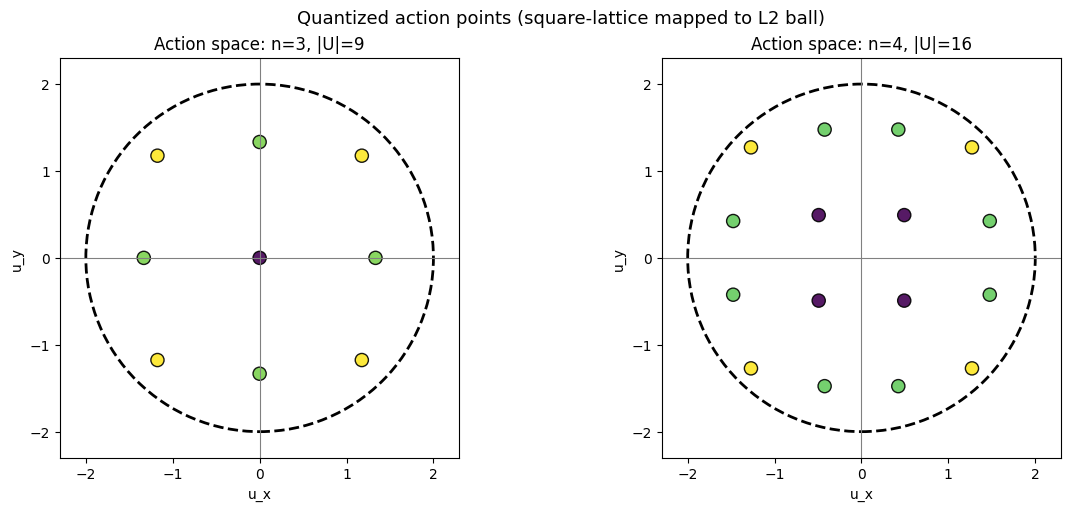

In [5]:
# Action quantization visuals for n=3,4
max_acc = 2.0
levels = [3, 4]

fig, axes = plt.subplots(1, len(levels), figsize=(12, 5), constrained_layout=True)
for ax, n in zip(axes, levels):
    aq = ActionQuantizer(max_acc=max_acc, n=n)
    U = to_numpy(aq.U)
    mags = np.linalg.norm(U, axis=1)

    ax.scatter(U[:, 0], U[:, 1], c=mags, cmap='viridis', s=90, edgecolor='k', alpha=0.9)
    ax.add_patch(Circle((0, 0), max_acc, fill=False, linestyle='--', linewidth=2, color='black'))
    ax.axhline(0.0, color='gray', linewidth=0.8)
    ax.axvline(0.0, color='gray', linewidth=0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.15 * max_acc, 1.15 * max_acc)
    ax.set_ylim(-1.15 * max_acc, 1.15 * max_acc)
    ax.set_title(f'Action space: n={n}, |U|={U.shape[0]}')
    ax.set_xlabel('u_x')
    ax.set_ylabel('u_y')

fig.suptitle('Quantized action points (square-lattice mapped to L2 ball)', fontsize=13)
plt.show()


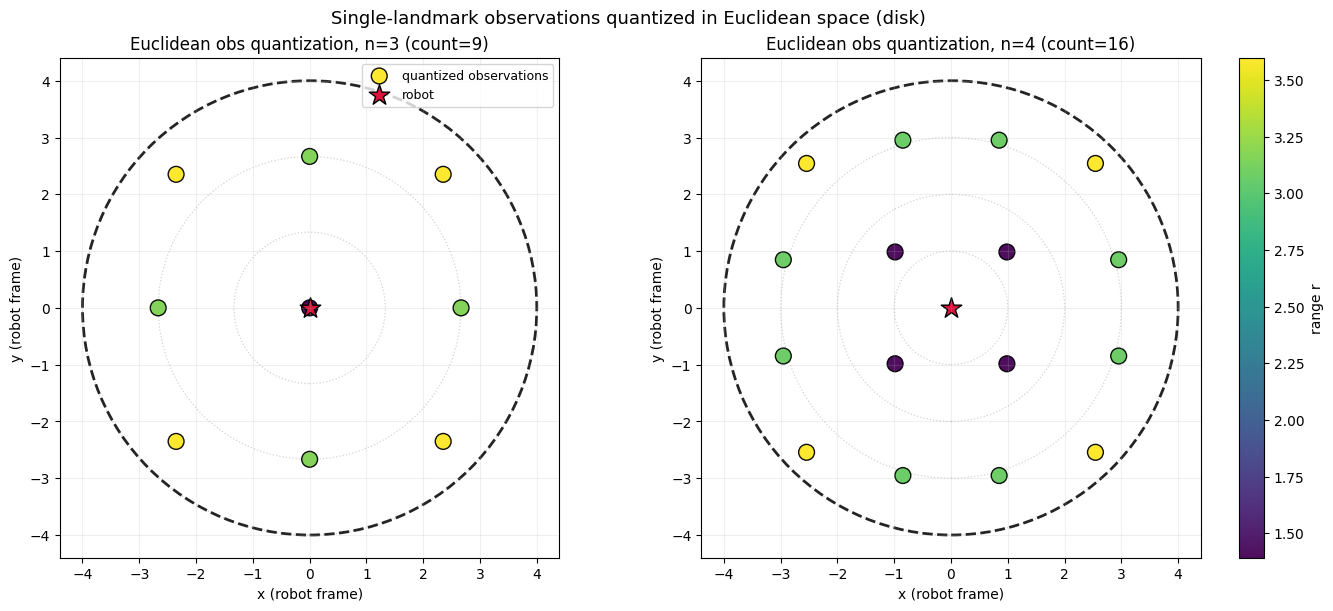

In [6]:
# Euclidean (action-like) quantization for SINGLE-landmark observations (n=3,4)
# This is an alternative to uniform (r, phi) bins and is more uniform in R^2.
r_max = 4.0
levels = [3, 4]

fig, axes = plt.subplots(1, len(levels), figsize=(14, 6), constrained_layout=True)
for ax, n in zip(axes, levels):
    xy, rp = build_euclidean_observation_points(n, r_max=r_max)
    r = rp[:, 0]

    # Polar bin guides for interpretation only (not used for quantization).
    guide_rings = np.linspace(0.0, r_max, n + 1)[1:]
    for rr in guide_rings:
        ax.add_patch(Circle((0.0, 0.0), rr, fill=False, linestyle=':', linewidth=0.9, color='gray', alpha=0.35))

    sc = ax.scatter(xy[:, 0], xy[:, 1], c=r, cmap='viridis', s=130, edgecolor='k', alpha=0.95, label='quantized observations')
    ax.scatter([0.0], [0.0], marker='*', s=240, color='crimson', edgecolor='k', label='robot')

    ax.add_patch(Circle((0.0, 0.0), r_max, fill=False, linestyle='--', linewidth=2.0, color='black', alpha=0.85))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.1 * r_max, 1.1 * r_max)
    ax.set_ylim(-1.1 * r_max, 1.1 * r_max)
    ax.set_title(f'Euclidean obs quantization, n={n} (count={xy.shape[0]})')
    ax.set_xlabel('x (robot frame)')
    ax.set_ylabel('y (robot frame)')
    ax.grid(alpha=0.2)

fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.03, label='range r')
axes[0].legend(loc='upper right', fontsize=9)
fig.suptitle('Single-landmark observations quantized in Euclidean space (disk)', fontsize=13)
plt.show()


In [7]:
# Compatibility check: keep observations stored as (r, phi) even with Euclidean spacing
# This is the representation downstream code expects.
r_max = 4.0
for n in [3, 4]:
    xy, rp = build_euclidean_observation_points(n, r_max=r_max)

    # Reconstruct Cartesian from stored (r, phi) and verify consistency.
    x_rec = rp[:, 0] * np.cos(rp[:, 1])
    y_rec = rp[:, 0] * np.sin(rp[:, 1])
    recon_err = np.max(np.sqrt((xy[:, 0] - x_rec) ** 2 + (xy[:, 1] - y_rec) ** 2))

    print(f"n={n}: |Y_single|={xy.shape[0]}, max reconstruction error={recon_err:.3e}")
    print('  first 5 stored observations [r, phi]:')
    print(np.round(rp[:5], 4))

# NOTE:
# If/when you wire this into BeliefMDP_n, keep Y_n encoded as [r1, phi1, r2, phi2, ...]
# (plus sentinel handling if desired) so existing codepaths stay compatible.


n=3: |Y_single|=9, max reconstruction error=0.000e+00
  first 5 stored observations [r, phi]:
[[ 3.3259 -2.3562]
 [ 2.6667 -1.5708]
 [ 3.3259 -0.7854]
 [ 2.6667 -3.1416]
 [ 0.     -2.3562]]
n=4: |Y_single|=16, max reconstruction error=0.000e+00
  first 5 stored observations [r, phi]:
[[ 3.5969 -2.3562]
 [ 3.0721 -1.8504]
 [ 3.0721 -1.2912]
 [ 3.5969 -0.7854]
 [ 3.0721 -2.862 ]]


In [8]:
# Cardinality sanity checks for current core observation quantization (Euclidean + sentinel)
levels = [3, 4]
landmark_counts = [1, 2, 3, 4]

print('Core mode appends sentinel [nan, nan] per landmark.')
print('Per-landmark size = |U_n| + 1, where |U_n| are finite Euclidean quantized points.')
print('-' * 104)
print(f"{'n':>4} {'L':>4} {'core |Y_n|=(|U_n|+1)^L':>30} {'no-sentinel reference (|U_n|)^L':>36} {'|U_n|':>10}")
print('-' * 104)
for n in levels:
    u_n = build_euclidean_observation_points(n, r_max=4.0)[0].shape[0]
    for L in landmark_counts:
        core_with_sentinel = (u_n + 1) ** L
        no_sentinel = u_n ** L
        print(f"{n:>4} {L:>4} {core_with_sentinel:>30} {no_sentinel:>36} {u_n:>10}")


Sentinel handling note: core logic appends [nan, nan] in BOTH polar and euclidean modes.
So per-landmark size in euclidean mode is |U_n| + 1 (not just |U_n|).
--------------------------------------------------------------------------------------------------------------------------------
   n    L       legacy (n^2+1)^L     euclid with sentinel (|U_n|+1)^L      euclid no sentinel (|U_n|)^L      |U_n|
--------------------------------------------------------------------------------------------------------------------------------
   3    1                     10                                   10                                 9          9
   3    2                    100                                  100                                81          9
   3    3                   1000                                 1000                               729          9
   3    4                  10000                                10000                              6561          9
   4    

In [9]:
# Core-logic test: verify new mode returns r,phi representation from Euclidean-spaced centers
for n in [3, 4]:
    rp_euclid, b_euclid = BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(
        obs_n=n,
        r_max=4.0,
        epsilon=0.1,
    )
    rp_polar, _ = BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(
        obs_n=n,
        r_max=4.0,
        epsilon=0.1,
    )

    # Stored format compatibility: [r, phi]
    assert rp_euclid.shape[1] == 2
    assert b_euclid.shape[1:] == (2, 2)

    # Euclidean mode keeps same per-landmark cardinality as polar mode (n^2 before sentinel).
    assert rp_euclid.shape[0] == rp_polar.shape[0] == n**2

    # r,phi values should be finite and in expected ranges.
    assert np.all(np.isfinite(rp_euclid))
    assert np.all(rp_euclid[:, 0] >= 0.0)
    assert np.all(rp_euclid[:, 0] <= 4.0 + 1e-12)
    assert np.all(rp_euclid[:, 1] >= -np.pi - 1e-12)
    assert np.all(rp_euclid[:, 1] < np.pi + 1e-12)

    print(f'n={n}: core euclidean mode OK | per-landmark points={rp_euclid.shape[0]}')


n=3: core euclidean mode OK | per-landmark points=9
n=4: core euclidean mode OK | per-landmark points=16


In [10]:
# Validate sentinel presence in Y_n exactly as core logic builds it
# (per-landmark points + sentinel, then Cartesian product across landmarks)
for n in [3, 4]:
    per_landmark_points, per_landmark_bounds = BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(
        obs_n=n,
        r_max=4.0,
        epsilon=0.1,
    )

    # Append sentinel exactly like _configure_observation_quantization_from_map
    per_landmark_points = np.vstack([per_landmark_points, np.array([[np.nan, np.nan]])])
    per_landmark_bounds = np.vstack([
        per_landmark_bounds,
        np.array([[[np.nan, np.nan], [np.nan, np.nan]]]),
    ])

    print(f"\n=== n={n} ===")
    print(f"per-landmark total = {per_landmark_points.shape[0]} (finite={n**2}, sentinel=1)")

    # L=1: Y_n should directly include one sentinel row
    Y1 = per_landmark_points.copy()
    sentinel_mask_1 = np.isnan(Y1).all(axis=1)
    print(f"L=1 |Y_n|={Y1.shape[0]}, sentinel_rows={sentinel_mask_1.sum()} (expected 1)")

    # L=2: Cartesian product, sentinel appears whenever either landmark is sentinel
    n_points = per_landmark_points.shape[0]
    idx_grid = np.indices((n_points, n_points)).reshape(2, -1).T
    Y2 = per_landmark_points[idx_grid].reshape(-1, 4)  # [r1,phi1,r2,phi2]
    sentinel_mask_2 = np.isnan(Y2.reshape(-1, 2, 2)).all(axis=2).any(axis=1)
    print(f"L=2 |Y_n|={Y2.shape[0]}, rows-with-any-sentinel={sentinel_mask_2.sum()} (expected {(n_points**2 - (n_points-1)**2)})")

    # Quick explicit check
    assert sentinel_mask_1.sum() == 1
    assert sentinel_mask_2.sum() == (n_points**2 - (n_points - 1)**2)

print('\nSentinel validation passed.')



=== n=3 ===
per-landmark total = 10 (finite=9, sentinel=1)
L=1 |Y_n|=10, sentinel_rows=1 (expected 1)
L=2 |Y_n|=100, rows-with-any-sentinel=19 (expected 19)

=== n=4 ===
per-landmark total = 17 (finite=16, sentinel=1)
L=1 |Y_n|=17, sentinel_rows=1 (expected 1)
L=2 |Y_n|=289, rows-with-any-sentinel=33 (expected 33)

Sentinel validation passed.


## Sweep-Aligned Quantization Sanity Checks

Checks below mirror the concrete setup in `notebooks/mapping/cost_comparisons/model_consistent_sweep.ipynb`:
- `pose_n=4`, `map_n=4`, `M=5`
- `action_n=8`, `obs_n=3`
- `LandmarkMap(..., n=4, num_landmarks=1)`
- `SingleIntegratorModel(..., max_v=4.0)`
- `RangeBearingSensor(r_max=4.0, epsilon=0.1, sigma_r in {0.5,0.75,1,1.25}, sigma_phi in {0.3,0.5,0.7})`

The goal is to verify **all quantized quantities and dimensions** before full sweeps.

In [11]:
from math import comb
from src.classes.mapping import LandmarkMap
from src.classes.model import SingleIntegratorModel
from src.classes.quantizer import StateQuantizer

# Mirror model_consistent_sweep defaults
pose_n = 4
map_n = 4
M = 5
obs_n = 3
action_n = 8

sigma_r_grid = [0.5, 0.75, 1.0, 1.25]
sigma_phi_grid = [0.3, 0.5, 0.7]

landmark_map = LandmarkMap(
    x_min=0.0, x_max=10.0,
    y_min=0.0, y_max=10.0,
    n=map_n,
    num_landmarks=1,
)
motion_model = SingleIntegratorModel(i_x=5.0, i_y=5.0, dt=1.0, max_v=4.0)

# Quantized state/action spaces used by the sweep
SQ = StateQuantizer((0.0, 10.0, 0.0, 10.0), pose_n)
AQ = ActionQuantizer(max_acc=motion_model.max_v, n=action_n)

X_n = to_numpy(SQ.X_n)
U_n = to_numpy(AQ.U)

# Observation quantization per landmark (core logic), both modes
    rp_core, b_core = BaseBeliefMDP_n.build_range_bearing_per_landmark_quantization(
        obs_n=obs_n, r_max=4.0, epsilon=0.1
    )

    # Append sentinel exactly as core logic does
    rp_core_full = np.vstack([rp_core, np.array([[np.nan, np.nan]])])

# Expected dimensions from sweep setup
L = int(landmark_map.num_candidate_landmarks)  # number of landmarks in RB observation vector
expected_m_n = pose_n ** 2                      # single integrator 2D lattice
expected_n_u = action_n ** 2                    # action quantizer points
expected_len_M = (map_n ** 2) ** L              # LandmarkMap len_M
expected_per_landmark_obs = obs_n ** 2 + 1      # + sentinel
expected_m_y = expected_per_landmark_obs ** L

# Belief quantizer cardinality for BeliefMDP_n_M_Mapping (N_n = len_M)
expected_BQ_cardinality = comb(M + expected_len_M - 1, expected_len_M - 1)

# Assertions
assert X_n.shape == (expected_m_n, 2), f"X_n shape mismatch: {X_n.shape}"
assert U_n.shape[0] == expected_n_u and U_n.shape[1] == 2, f"U_n shape mismatch: {U_n.shape}"
assert landmark_map.len_M == expected_len_M, f"len_M mismatch: {landmark_map.len_M}"

assert rp_core_full.shape == (expected_per_landmark_obs, 2)
assert np.isnan(rp_core_full).all(axis=1).sum() == 1

# Core mode stores observations as [r,phi]
finite_e = ~np.isnan(rp_core_full).any(axis=1)
assert np.all(np.isfinite(rp_core_full[finite_e]))
assert np.all(rp_core_full[finite_e, 0] >= 0.0)
assert np.all(rp_core_full[finite_e, 0] <= 4.0 + 1e-12)
assert np.all(rp_core_full[finite_e, 1] >= -np.pi - 1e-12)
assert np.all(rp_core_full[finite_e, 1] < np.pi + 1e-12)

# cov_y dimension checks used by sweep builder
for sr in sigma_r_grid:
    for sp in sigma_phi_grid:
        cov_y = np.diag(np.tile([sr**2, sp**2], L))
        assert cov_y.shape == (2 * L, 2 * L)

print('Sweep-aligned quantization checks passed.')
print('-' * 72)
print(f'pose_n={pose_n} -> |X_n|={X_n.shape[0]} (expected {expected_m_n})')
print(f'action_n={action_n} -> |U_n|={U_n.shape[0]} (expected {expected_n_u})')
print(f'map_n={map_n}, L={L} -> len_M={landmark_map.len_M} (expected {expected_len_M})')
print(f'obs_n={obs_n} per-landmark size (core euclidean + sentinel): {rp_core_full.shape[0]} (expected {expected_per_landmark_obs})')
print(f'full |Y_n| for L={L}: {expected_m_y}')
print(f'Belief codebook size comb(M+len_M-1, len_M-1) with M={M}: {expected_BQ_cardinality}')


Sweep-aligned quantization checks passed.
------------------------------------------------------------------------
pose_n=4 -> |X_n|=16 (expected 16)
action_n=8 -> |U_n|=64 (expected 64)
map_n=4, L=1 -> len_M=16 (expected 16)
obs_n=3 per-landmark size: polar=10, euclid=10 (expected 10)
full |Y_n| for L=1: 10
Belief codebook size comb(M+len_M-1, len_M-1) with M=5: 15504


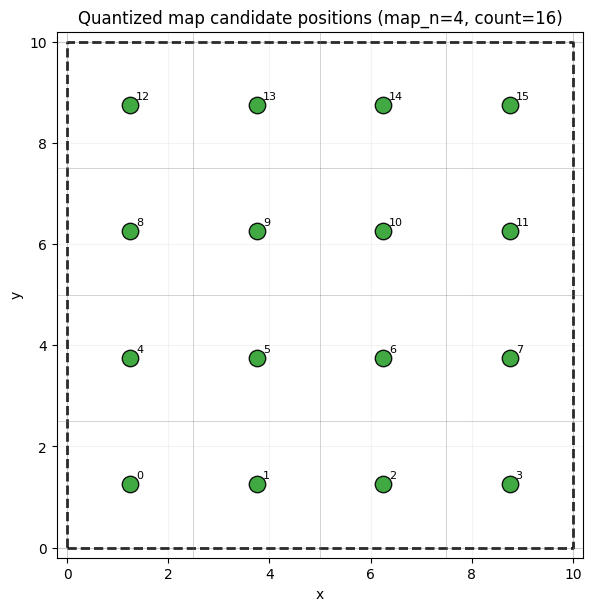

In [12]:
# Visual sanity check: quantized MAP candidate set (LandmarkMap grid)
# Uses the sweep-aligned map_n and workspace bounds.

# Candidate landmark positions are the quantized workspace cells for the map.
map_points = np.asarray(landmark_map.cell_centers)

fig, ax = plt.subplots(figsize=(6.5, 6.0), constrained_layout=True)
ax.scatter(map_points[:, 0], map_points[:, 1], s=140, color='#2ca02c', edgecolor='k', alpha=0.9)

# Draw workspace boundary
ax.plot([0, 10, 10, 0, 0], [0, 0, 10, 10, 0], 'k--', linewidth=1.8)

# Draw grid lines for map quantization cells
grid_vals = np.linspace(0.0, 10.0, map_n + 1)
for gv in grid_vals:
    ax.axhline(gv, color='gray', linewidth=0.7, alpha=0.35)
    ax.axvline(gv, color='gray', linewidth=0.7, alpha=0.35)

for i, (x, y) in enumerate(map_points):
    ax.text(x + 0.12, y + 0.12, str(i), fontsize=8, color='black')

ax.set_title(f'Quantized map candidate positions (map_n={map_n}, count={map_points.shape[0]})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-0.2, 10.2)
ax.set_ylim(-0.2, 10.2)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.15)
plt.show()


AttributeError: 'SingleIntegratorModel' object has no attribute 'i_x'

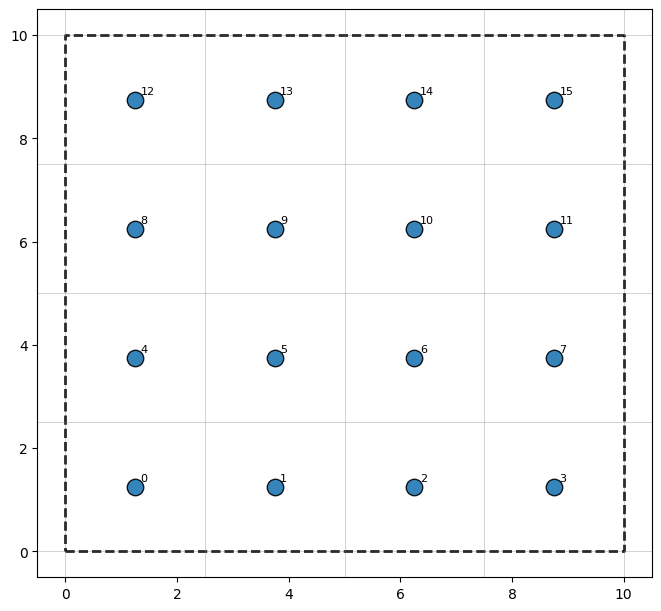

In [13]:
# Visual sanity check: quantized STATE space for SingleIntegrator (pose lattice)
# Uses the sweep-aligned pose_n and workspace bounds.

state_points = np.asarray(X_n)  # from sweep-aligned sanity cell

fig, ax = plt.subplots(figsize=(6.5, 6.0), constrained_layout=True)
ax.scatter(state_points[:, 0], state_points[:, 1], s=140, color='#1f77b4', edgecolor='k', alpha=0.9)

# Draw workspace boundary and quantization cell lines
ax.plot([0, 10, 10, 0, 0], [0, 0, 10, 10, 0], 'k--', linewidth=1.8)
state_grid_vals = np.linspace(0.0, 10.0, pose_n + 1)
for gv in state_grid_vals:
    ax.axhline(gv, color='gray', linewidth=0.7, alpha=0.35)
    ax.axvline(gv, color='gray', linewidth=0.7, alpha=0.35)

for i, (x, y) in enumerate(state_points):
    ax.text(x + 0.10, y + 0.10, str(i), fontsize=8, color='black')

ax.scatter([motion_model.i_x], [motion_model.i_y], marker='*', s=260, color='crimson', edgecolor='k', label='initial state')

ax.set_title(f'Quantized single-integrator state lattice (pose_n={pose_n}, count={state_points.shape[0]})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-0.2, 10.2)
ax.set_ylim(-0.2, 10.2)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.15)
plt.show()
